# BodyM: Body Measurement Estimation from Silhouettes
### Complete Pipeline: Preprocessing → Training → Evaluation
**Architecture:** Dual-Branch MobileNetV3Small + Gender Auxiliary Input → 15 Body Measurements  
**Framework:** PyTorch (consistent throughout)  
**Platform:** Kaggle GPU (T4/P100)

## 1. Setup & Configuration

In [1]:
# ─── Install / verify dependencies ───────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'timm', '-q'])

import os, random, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm

warnings.filterwarnings('ignore')
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch version : 2.9.0+cu126
CUDA available  : True
GPU             : Tesla T4


In [3]:
# ─── Global Config ────────────────────────────────────────────────────────────
DATA_ROOT  = '/kaggle/input/datasets/aminalawal/bodym-dataset/bodym-data'
TRAIN_DIR  = os.path.join(DATA_ROOT, 'train')
OUTPUT_DIR = '/kaggle/working'

# Device first — everything else depends on it
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Training hyper-parameters
IMG_SIZE      = 224
BATCH_SIZE    = 32
PHASE1_LR     = 3e-4
PHASE2_LR     = 5e-5
PHASE1_EPOCHS = 30
PHASE2_EPOCHS = 40
NUM_WORKERS   = 2
SEED          = 42

# Measurements
MEASUREMENT_COLS = [
    'ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm',
    'height', 'hip', 'leg-length', 'shoulder-breadth',
    'shoulder-to-crotch', 'thigh', 'waist', 'wrist'
]
NUM_OUTPUTS = len(MEASUREMENT_COLS)   # 14



AUX_COLS = ['height_cm', 'weight_kg']

print(f'Predicting {NUM_OUTPUTS} measurements: {MEASUREMENT_COLS}')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Using device: cuda
Predicting 14 measurements: ['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip', 'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist']


In [4]:
for root, dirs, files in os.walk('/kaggle/input/datasets/aminalawal/bodym-dataset'):
    level = root.replace('/kaggle/input/datasets/aminalawal/bodym-dataset', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:  # only show 3 levels deep
        for f in files[:3]:
            print(f'{indent}  {f}')

bodym-dataset/
  bodym-data/
    testB/
      subject_to_photo_map.csv
      hwg_metadata.csv
      measurements.csv
      mask_left/
      mask/
    testA/
      subject_to_photo_map.csv
      measurements.csv
      mask_left/
      mask/
    train/
      subject_to_photo_map.csv
      hwg_metadata.csv
      measurements.csv
      mask_left/
      mask/


## 2. Load & Merge Raw Data

In [5]:
# ─── Load CSVs ────────────────────────────────────────────────────────────────
subject_map  = pd.read_csv(os.path.join(TRAIN_DIR, 'subject_to_photo_map.csv'))
measurements = pd.read_csv(os.path.join(TRAIN_DIR, 'measurements.csv'))
hwg          = pd.read_csv(os.path.join(TRAIN_DIR, 'hwg_metadata.csv'))

print('subject_map :', subject_map.shape)
print('measurements:', measurements.shape)
print('hwg_metadata:', hwg.shape)

# Merging: measurements + height/weight/gender + photo_ids
df = (
    measurements
    .merge(hwg,         on='subject_id', how='inner')
    .merge(subject_map, on='subject_id', how='inner')
)

print(f'\nMerged dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
if df.isnull().sum().sum() == 0:
    print('No missing values')
df.head(3)

subject_map : (6134, 2)
measurements: (2018, 15)
hwg_metadata: (2018, 4)

Merged dataset shape: (6134, 19)
Columns: ['subject_id', 'ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip', 'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist', 'gender', 'height_cm', 'weight_kg', 'photo_id']

Missing values:
Series([], dtype: int64)
✓ No missing values


,subject_id,ankle,arm-length,bicep,calf,chest,forearm,height,hip,leg-length,shoulder-breadth,shoulder-to-crotch,thigh,waist,wrist,gender,height_cm,weight_kg,photo_id
0,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,e6f404ebda41ebe93573d3e219c88297
1,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,39a4241cb892618a694747e224d57b9e
2,-494U-YoXOD8e8gkCuyaRLn4MLo5P8Dm2B1s59WBGdg,24.343954,52.902378,33.294395,38.709511,102.526024,27.599094,177.610992,108.047134,81.736435,35.915691,67.891273,57.872795,92.286171,16.709131,male,178.0,79.6,a00a6c0c074efbd92c894cbc77023939


In [6]:
# ─── Dropping rows where image files are missing ──────────────────────────────────
mask_dir      = os.path.join(TRAIN_DIR, 'mask')
mask_left_dir = os.path.join(TRAIN_DIR, 'mask_left')

def both_images_exist(photo_id):
    return (
        os.path.exists(os.path.join(mask_dir,      f'{photo_id}.png')) and
        os.path.exists(os.path.join(mask_left_dir, f'{photo_id}.png'))
    )

mask = df['photo_id'].apply(both_images_exist)
df   = df[mask].copy().reset_index(drop=True)
print(f'Samples with both images present: {len(df)}')
print(f'Unique subjects: {df["subject_id"].nunique()}')

Samples with both images present: 6119
Unique subjects: 2016


## 3. Exploratory Data Analysis

In [7]:
# ─── Gender distribution & measurement statistics ─────────────────────────────
print('Gender distribution:')
print(df['gender'].value_counts())
print()
print(df[MEASUREMENT_COLS + ['height_cm', 'weight_kg']].describe().round(2))

Gender distribution:
gender
male      3637
female    2482
Name: count, dtype: int64

         ankle  arm-length    bicep     calf    chest  forearm   height  \
count  6119.00     6119.00  6119.00  6119.00  6119.00  6119.00  6119.00   
mean     24.22       49.58    30.65    37.51   102.23    26.61   172.18   
std       1.87        3.25     4.06     3.26    11.42     2.72     9.58   
min      19.24       39.39    19.13    28.27    77.08    18.88   140.86   
25%      22.84       47.31    27.91    35.24    94.27    24.70   165.05   
50%      24.24       49.69    30.41    37.26   101.48    26.61   172.38   
75%      25.48       51.70    32.89    39.41   108.49    28.38   179.08   
max      32.98       59.43    55.81    55.33   153.94    39.75   197.51   

           hip  leg-length  shoulder-breadth  shoulder-to-crotch    thigh  \
count  6119.00     6119.00           6119.00             6119.00  6119.00   
mean    103.15       78.31             35.85               65.05    54.37   
std     

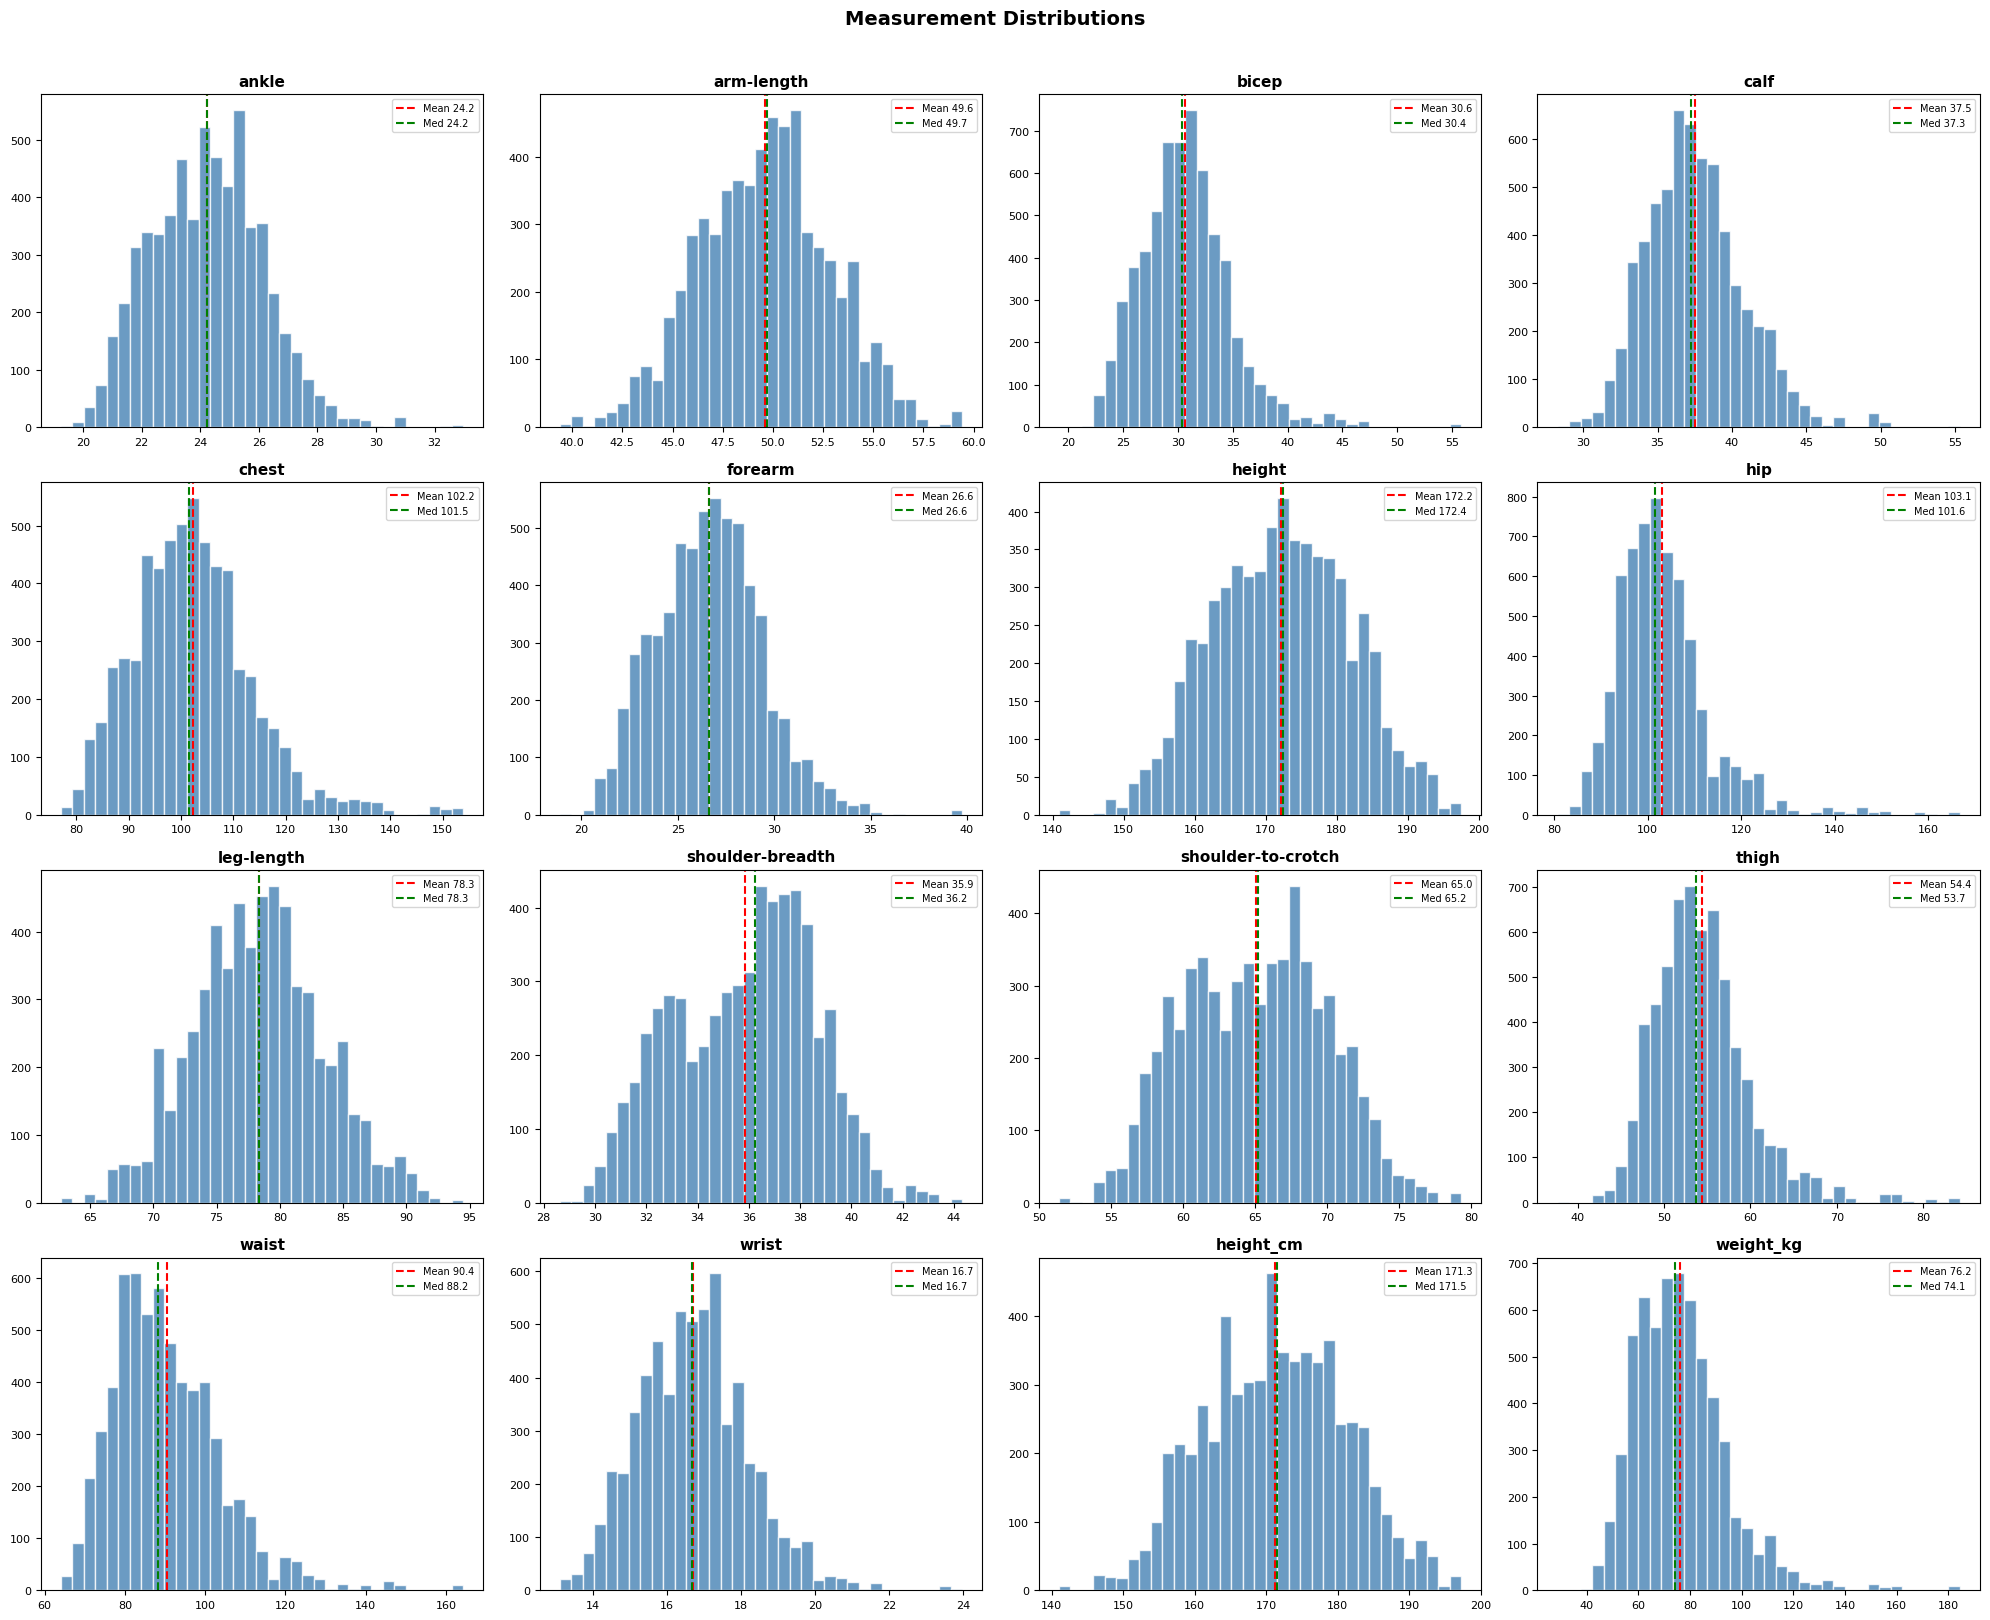

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.ravel()
plot_cols = MEASUREMENT_COLS + ['height_cm', 'weight_kg']

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=35, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(),   color='red',   linestyle='--', lw=1.5, label=f'Mean {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', lw=1.5, label=f'Med {df[col].median():.1f}')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=8)

# Hide the empty 16th subplot (4×4=16, we have 16 cols so actually perfect)
# But if you ever add/remove cols, this safely hides any extras:
for j in range(len(plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Measurement Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

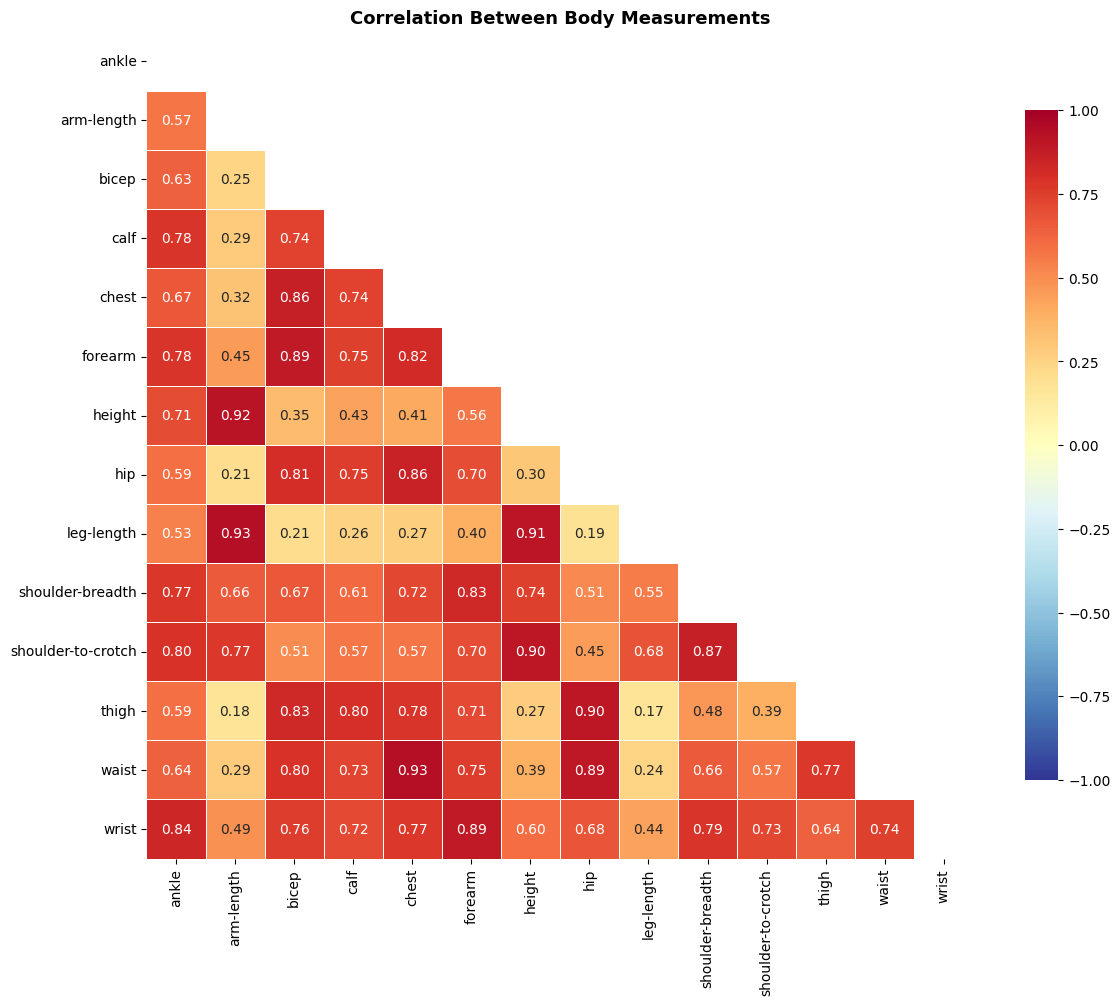

In [10]:
# ─── Correlation heatmap ──────────────────────────────────────────────────────
plt.figure(figsize=(12, 10))
corr = df[MEASUREMENT_COLS].corr()
mask_tri = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_tri, annot=True, fmt='.2f',
            cmap='RdYlBu_r', square=True, linewidths=0.5,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Between Body Measurements', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

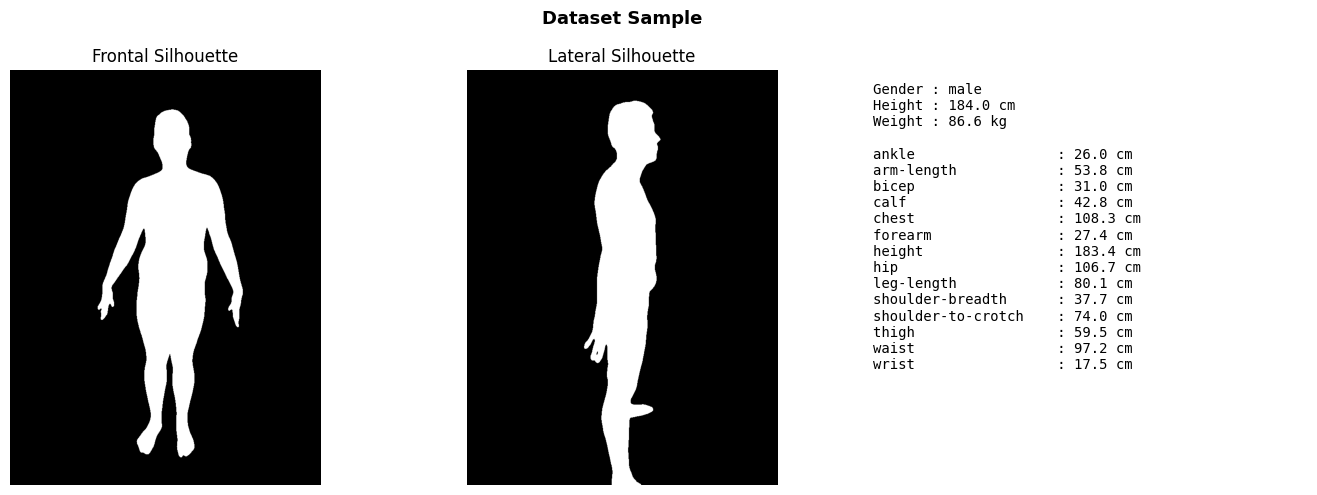

In [11]:
# ─── Sample silhouette visualization ─────────────────────────────────────────
def show_sample(photo_id, row, title='Sample'):
    front = cv2.imread(os.path.join(mask_dir,      f'{photo_id}.png'), 0)
    side  = cv2.imread(os.path.join(mask_left_dir, f'{photo_id}.png'), 0)

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    axes[0].imshow(front, cmap='gray'); axes[0].set_title('Frontal Silhouette'); axes[0].axis('off')
    axes[1].imshow(side,  cmap='gray'); axes[1].set_title('Lateral Silhouette'); axes[1].axis('off')

    axes[2].axis('off')
    txt = f"Gender : {row['gender']}\nHeight : {row['height_cm']:.1f} cm\nWeight : {row['weight_kg']:.1f} kg\n\n"
    txt += '\n'.join([f"{c:<22}: {row[c]:.1f} cm" for c in MEASUREMENT_COLS])
    axes[2].text(0.05, 0.97, txt, transform=axes[2].transAxes, fontsize=10,
                 verticalalignment='top', family='monospace')
    plt.tight_layout()
    plt.show()

sample_row = df.iloc[np.random.randint(len(df))]
show_sample(sample_row['photo_id'], sample_row, 'Dataset Sample')

## 4. Train / Val / Test Split

In [12]:
# ─── Splitting by SUBJECT to prevent data leakage ─────────────────────────────────
# Photos of the same person must never be split across train and val/test.
unique_subjects = df['subject_id'].unique()

train_subj, temp_subj = train_test_split(unique_subjects, test_size=0.30, random_state=SEED)
val_subj,  test_subj  = train_test_split(temp_subj,       test_size=0.50, random_state=SEED)

train_df = df[df['subject_id'].isin(train_subj)].reset_index(drop=True)
val_df   = df[df['subject_id'].isin(val_subj)  ].reset_index(drop=True)
test_df  = df[df['subject_id'].isin(test_subj) ].reset_index(drop=True)

print(f'Train : {len(train_df):>4} photos from {len(train_subj):>4} subjects')
print(f'Val   : {len(val_df):>4} photos from {len(val_subj):>4} subjects')
print(f'Test  : {len(test_df):>4} photos from {len(test_subj):>4} subjects')

# Sanity-check: no subject overlap
assert len(set(train_subj) & set(val_subj))  == 0, 'Train/Val overlap!'
assert len(set(train_subj) & set(test_subj)) == 0, 'Train/Test overlap!'
assert len(set(val_subj)   & set(test_subj)) == 0, 'Val/Test overlap!'
print(' No subject overlap across splits')

# Save split CSVs (lightweight — no image arrays)
train_df.to_csv(os.path.join(OUTPUT_DIR, 'train_split.csv'), index=False)
val_df.to_csv(  os.path.join(OUTPUT_DIR, 'val_split.csv'),   index=False)
test_df.to_csv( os.path.join(OUTPUT_DIR, 'test_split.csv'),  index=False)
print('Split CSVs saved to', OUTPUT_DIR)

Train : 4338 photos from 1411 subjects
Val   :  837 photos from  302 subjects
Test  :  944 photos from  303 subjects
✓ No subject overlap across splits
✓ Split CSVs saved to /kaggle/working


## 5. Label Normalization

In [13]:
# ─── Fitting scaler ONLY on train labels ──────────────────────────────────────────
# normalizing targets so the optimizer treats all measurements equally.
# At evaluation time, ALWAYS inverse-transform back to cm to report real MAE.
scaler = StandardScaler()
scaler.fit(train_df[MEASUREMENT_COLS])

with open(os.path.join(OUTPUT_DIR, 'label_scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

print('Scaler means (cm):')
for col, mean in zip(MEASUREMENT_COLS, scaler.mean_):
    print(f'  {col:<24}: {mean:.2f}')
print(f'\n Scaler saved → {OUTPUT_DIR}/label_scaler.pkl')

Scaler means (cm):
  ankle                   : 24.21
  arm-length              : 49.47
  bicep                   : 30.59
  calf                    : 37.53
  chest                   : 102.03
  forearm                 : 26.58
  height                  : 171.96
  hip                     : 103.04
  leg-length              : 78.15
  shoulder-breadth        : 35.81
  shoulder-to-crotch      : 64.99
  thigh                   : 54.37
  waist                   : 90.25
  wrist                   : 16.69

✓ Scaler saved → /kaggle/working/label_scaler.pkl


## 6. Dataset & DataLoader

In [14]:
# ─── Augmentation transforms ──────────────────────────────────────────────────
# Silhouettes are binary masks → be conservative with augmentation.
# flipping BOTH views consistently and apply shared affine transforms.

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(split):
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomAffine(
                degrees=5,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05)
            ),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

print('Train transforms:', get_transforms('train'))
print()
print('Val/Test transforms:', get_transforms('val'))

Train transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomAffine(degrees=[-5.0, 5.0], translate=(0.05, 0.05), scale=(0.95, 1.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [15]:
class BodyMDataset(Dataset):
    """
    Lazy-loading Dataset for BodyM silhouette images.

    Returns:
        front_img : (3, H, W)  frontal silhouette (grayscale → RGB repeat)
        side_img  : (3, H, W)  lateral silhouette (grayscale → RGB repeat)
        aux       : (3,)       gender + height_cm + weight_kg
        labels    : (N,)       normalized body measurements
    """

    GENDER_MAP = {'female': 0, 'male': 1, 'f': 0, 'm': 1}

    def __init__(self, df, scaler, mask_dir, mask_left_dir,
                 measurement_cols, split='train', transform=None):
        self.df               = df.reset_index(drop=True)
        self.scaler           = scaler
        self.mask_dir         = mask_dir
        self.mask_left_dir    = mask_left_dir
        self.measurement_cols = measurement_cols
        self.split            = split
        self.transform        = transform or get_transforms(split)

        # Pre-compute normalized labels once
        raw_labels = df[measurement_cols].values.astype(np.float32)
        self.labels = scaler.transform(raw_labels).astype(np.float32)

    def __len__(self):
        return len(self.df)

    def _load_silhouette(self, path):
        """Load PNG silhouette, convert to 3-channel RGB-like tensor."""
        img = Image.open(path).convert('L')
        img = img.convert('RGB')
        return img

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        photo_id = row['photo_id']

        # Load both views
        front_img = self._load_silhouette(
            os.path.join(self.mask_dir,      f'{photo_id}.png')
        )
        side_img  = self._load_silhouette(
            os.path.join(self.mask_left_dir, f'{photo_id}.png')
        )

        # For training, apply the SAME random flip to both views
        if self.split == 'train' and random.random() < 0.5:
            front_img = transforms.functional.hflip(front_img)
            side_img  = transforms.functional.hflip(side_img)

        # Apply remaining transforms independently (non-flip parts)
        non_flip_tf = transforms.Compose([
            t for t in self.transform.transforms
            if not isinstance(t, transforms.RandomHorizontalFlip)
        ])
        front_tensor = non_flip_tf(front_img)
        side_tensor  = non_flip_tf(side_img)

        # Auxiliary inputs: gender + raw height + raw weight
        gender_val = float(self.GENDER_MAP.get(str(row['gender']).lower().strip(), 0))
        aux = torch.tensor([
            gender_val,
            float(row['height_cm']),
            float(row['weight_kg'])
        ], dtype=torch.float32)

        label = torch.from_numpy(self.labels[idx])
        return front_tensor, side_tensor, aux, label


# ─── Instantiate datasets ─────────────────────────────────────────────────────
train_dataset = BodyMDataset(train_df, scaler, mask_dir, mask_left_dir,
                             MEASUREMENT_COLS, split='train')
val_dataset   = BodyMDataset(val_df,   scaler, mask_dir, mask_left_dir,
                             MEASUREMENT_COLS, split='val')
test_dataset  = BodyMDataset(test_df,  scaler, mask_dir, mask_left_dir,
                             MEASUREMENT_COLS, split='test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Verify a single batch
front, side, aux, labels = next(iter(train_loader))
print(f'\nBatch shapes:')
print(f'  front  : {front.shape}    (B, 3, H, W)')
print(f'  side   : {side.shape}     (B, 3, H, W)')
print(f'  aux    : {aux.shape}      (B, 3)  ← gender, height_cm, weight_kg')
print(f'  labels : {labels.shape}   (B, {NUM_OUTPUTS})')

Train batches : 136
Val   batches : 27
Test  batches : 30

Batch shapes:
  front  : torch.Size([32, 3, 224, 224])    (B, 3, H, W)
  side   : torch.Size([32, 3, 224, 224])     (B, 3, H, W)
  aux    : torch.Size([32, 3])      (B, 3)  ← gender, height_cm, weight_kg
  labels : torch.Size([32, 14])   (B, 14)


## 7. Model Architecture — Dual-Branch MobileNetV3Small

In [16]:
class DualBranchBodyM(nn.Module):

    def __init__(self, num_outputs, pretrained=True, dropout=0.3):
        super().__init__()
        self.front_branch = self._build_backbone(pretrained)
        self.side_branch  = self._build_backbone(pretrained)
        feat_dim  = 1408   # EfficientNet-B2 output dim
        fused_dim = feat_dim * 2 + 3   # 2816 + 3 = 2819

        self.head = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_outputs),
        )

    @staticmethod
    def _build_backbone(pretrained):
        """EfficientNet-B2 → AdaptiveAvgPool → 1408-d feature vector."""
        backbone = models.efficientnet_b2(
            weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
        )
        backbone.classifier = nn.Identity()
        return backbone

    def freeze_backbones(self):
        for p in self.front_branch.parameters():
            p.requires_grad = False
        for p in self.side_branch.parameters():
            p.requires_grad = False
        print(' Backbones frozen — training head only')

    def unfreeze_backbones(self):
        for p in self.front_branch.parameters():
            p.requires_grad = True
        for p in self.side_branch.parameters():
            p.requires_grad = True
        print(' Backbones unfrozen — fine-tuning entire network')

    def forward(self, front_img, side_img, aux):
        front_feat = self.front_branch(front_img)          # (B, 1408)
        side_feat  = self.side_branch(side_img)            # (B, 1408)
        fused      = torch.cat([front_feat, side_feat, aux], dim=1)  # (B, 2819)
        return self.head(fused)


# ─── Build model ──────────────────────────────────────────────────────────────
model = DualBranchBodyM(num_outputs=NUM_OUTPUTS, pretrained=True).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

# Smoke-test
with torch.no_grad():
    dummy_out = model(front.to(DEVICE), side.to(DEVICE), aux.to(DEVICE))
print(f'Output shape         : {dummy_out.shape}   ')

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 154MB/s] 


Total parameters     : 16,982,290
Trainable parameters : 16,982,290
Output shape         : torch.Size([32, 14])   ✓


## 8. Training Utilities

In [17]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for front, side, aux, labels in loader:
        front, side    = front.to(device),  side.to(device)
        aux, labels    = aux.to(device),    labels.to(device)

        optimizer.zero_grad()
        preds = model(front, side, aux)
        loss  = F.huber_loss(preds, labels, delta=1.0)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * front.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, scaler, device):
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []
    for front, side, aux, labels in loader:
        front, side = front.to(device), side.to(device)
        aux, labels = aux.to(device),   labels.to(device)
        preds = model(front, side, aux)
        loss  = F.huber_loss(preds, labels, delta=1.0)
        total_loss += loss.item() * front.size(0)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    preds_cm   = scaler.inverse_transform(all_preds)
    labels_cm  = scaler.inverse_transform(all_labels)
    mae_per_col = np.abs(preds_cm - labels_cm).mean(axis=0)
    mean_mae_cm = mae_per_col.mean()
    return total_loss / len(loader.dataset), mae_per_col, mean_mae_cm

def run_training_phase(model, train_loader, val_loader, optimizer, scheduler,
                       scaler, device, num_epochs, phase_name, history):
    best_val_mae = float('inf')
    best_model_path = os.path.join(OUTPUT_DIR, 'best_bodym_model.pth')
    patience_counter = 0
    patience = 8

    print(f"\n{'='*65}")
    print(f" {phase_name}")
    print(f"{'='*65}")
    print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<14} {'Val MAE (cm)':<14} {'Best?'}")
    print('-' * 65)

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, device)
        val_loss, mae_per_col, val_mae = evaluate(model, val_loader, scaler, device)
        scheduler.step(val_loss)

        is_best = val_mae < best_val_mae
        if is_best:
            best_val_mae = val_mae
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_mae_cm': float(val_mae),
                'measurement_cols': MEASUREMENT_COLS,
            }, best_model_path)
        else:
            patience_counter += 1

        flag = 'BEST' if is_best else ''
        print(f'{epoch:<8} {train_loss:<14.4f} {val_loss:<14.4f} {val_mae:<14.3f} {flag}')

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae_cm'].append(val_mae)

        if patience_counter >= patience:
            print(f'  Early stopping triggered after {patience} epochs without improvement.')
            break

    print(f'\n  Best Val MAE: {best_val_mae:.3f} cm')
    return history, best_model_path


print(' Training utilities defined')

✓ Training utilities defined


## 9. Phase 1 — Train Head (Backbone Frozen)

In [18]:
history = {'train_loss': [], 'val_loss': [], 'val_mae_cm': []}

model.freeze_backbones()

optimizer1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR, weight_decay=1e-4
)
scheduler1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer1, mode='min', factor=0.5, patience=4
)

history, best_path = run_training_phase(
    model, train_loader, val_loader, optimizer1, scheduler1,
    scaler, DEVICE, PHASE1_EPOCHS, 'Phase 1: Head Training (Backbone Frozen)', history
)

✓ Backbones frozen — training head only

 Phase 1: Head Training (Backbone Frozen)
Epoch    Train Loss     Val Loss       Val MAE (cm)   Best?
-----------------------------------------------------------------
1        0.1579         0.0896         1.648          ★ BEST
2        0.1265         0.0854         1.586          ★ BEST
3        0.1158         0.0806         1.522          ★ BEST
4        0.1106         0.0786         1.517          ★ BEST
5        0.1086         0.0788         1.496          ★ BEST
6        0.1039         0.0773         1.454          ★ BEST
7        0.1035         0.0792         1.496          
8        0.0995         0.0761         1.452          ★ BEST
9        0.0989         0.0770         1.483          
10       0.0966         0.0770         1.467          
11       0.0969         0.0803         1.509          
12       0.0939         0.0761         1.456          
13       0.0921         0.0759         1.458          
14       0.0917         0.0819    

## 10. Phase 2 — Fine-tune Full Network

In [19]:
checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Loaded Phase 1 best model (val MAE = {checkpoint["val_mae_cm"]:.3f} cm)')

model.unfreeze_backbones()

optimizer2 = torch.optim.AdamW([
    {'params': model.front_branch.parameters(), 'lr': PHASE2_LR * 0.1},
    {'params': model.side_branch.parameters(),  'lr': PHASE2_LR * 0.1},
    {'params': model.head.parameters(),         'lr': PHASE2_LR},
], weight_decay=1e-4)

scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer2, T_max=PHASE2_EPOCHS, eta_min=1e-6
)

history, best_path = run_training_phase(
    model, train_loader, val_loader, optimizer2, scheduler2,
    scaler, DEVICE, PHASE2_EPOCHS, 'Phase 2: Full Fine-Tuning', history
)

Loaded Phase 1 best model (val MAE = 1.391 cm)
✓ Backbones unfrozen — fine-tuning entire network

 Phase 2: Full Fine-Tuning
Epoch    Train Loss     Val Loss       Val MAE (cm)   Best?
-----------------------------------------------------------------
1        0.0838         0.0720         1.411          ★ BEST
2        0.0844         0.0719         1.403          ★ BEST
3        0.0825         0.0726         1.394          ★ BEST
4        0.0804         0.0709         1.374          ★ BEST
5        0.0808         0.0675         1.338          ★ BEST
6        0.0796         0.0688         1.350          
7        0.0780         0.0688         1.355          
8        0.0781         0.0682         1.344          
9        0.0768         0.0662         1.322          ★ BEST
10       0.0768         0.0650         1.329          
11       0.0756         0.0671         1.320          ★ BEST
12       0.0750         0.0648         1.320          ★ BEST
13       0.0748         0.0655         1.

## 11. Training Curves

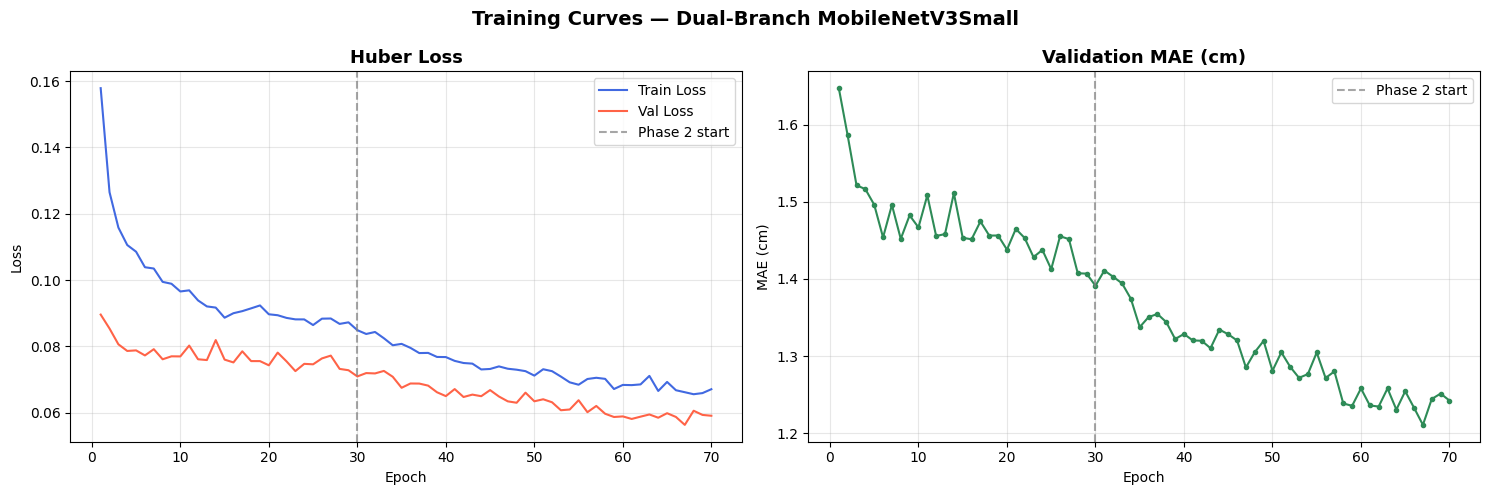

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

epochs = range(1, len(history['train_loss']) + 1)
phase1_end = min(PHASE1_EPOCHS, len(history['train_loss']))

axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].axvline(phase1_end, color='gray', linestyle='--', alpha=0.7, label='Phase 2 start')
axes[0].set_title('Huber Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_mae_cm'], color='seagreen', marker='o', markersize=3)
axes[1].axvline(phase1_end, color='gray', linestyle='--', alpha=0.7, label='Phase 2 start')
axes[1].set_title('Validation MAE (cm)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (cm)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training Curves — Dual-Branch MobileNetV3Small', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Final Evaluation on Test Set

In [22]:
checkpoint = torch.load(best_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded best model — val MAE during training: {checkpoint["val_mae_cm"]:.3f} cm')

test_loss, test_mae_per_col, test_mean_mae = evaluate(model, test_loader, scaler, DEVICE)

print(f'\n{"="*55}')
print(f' TEST SET RESULTS')
print(f'{"="*55}')
print(f' {"Measurement":<25} {"MAE (cm)":>10}')
print(f'{"-"*55}')
for col, mae in zip(MEASUREMENT_COLS, test_mae_per_col):
    print(f' {col:<25} {mae:>10.3f}')
print(f'{"="*55}')
print(f' {"MEAN MAE":<25} {test_mean_mae:>10.3f} cm')
print(f'{"="*55}')

Loaded best model — val MAE during training: 1.211 cm

 TEST SET RESULTS
 Measurement                 MAE (cm)
-------------------------------------------------------
 ankle                          0.610
 arm-length                     0.894
 bicep                          1.222
 calf                           0.986
 chest                          2.253
 forearm                        0.713
 height                         1.060
 hip                            1.942
 leg-length                     1.165
 shoulder-breadth               0.678
 shoulder-to-crotch             1.029
 thigh                          1.242
 waist                          2.280
 wrist                          0.483
 MEAN MAE                       1.183 cm


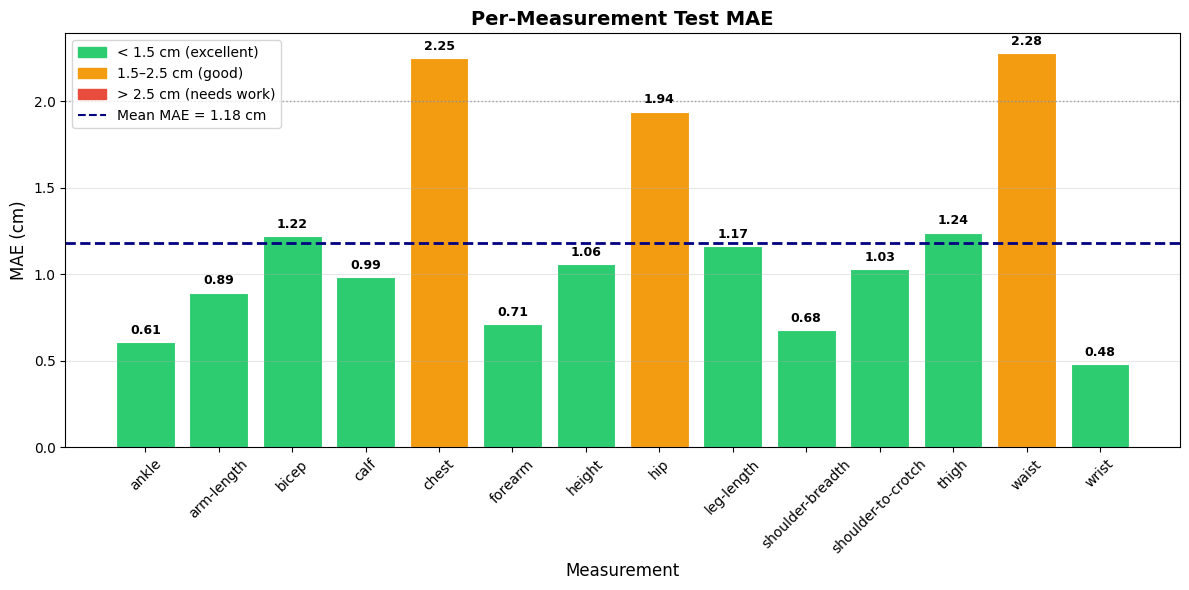

In [23]:
# ─── Per-measurement MAE bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2ecc71' if mae < 1.5 else '#f39c12' if mae < 2.5 else '#e74c3c'
          for mae in test_mae_per_col]

bars = ax.bar(MEASUREMENT_COLS, test_mae_per_col, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(test_mean_mae, color='navy', linestyle='--', lw=2,
           label=f'Mean MAE = {test_mean_mae:.2f} cm')
ax.axhline(2.0, color='gray', linestyle=':', lw=1, alpha=0.7, label='2 cm threshold')

for bar, mae in zip(bars, test_mae_per_col):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f'{mae:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_patches = [
    Patch(color='#2ecc71', label='< 1.5 cm (excellent)'),
    Patch(color='#f39c12', label='1.5–2.5 cm (good)'),
    Patch(color='#e74c3c', label='> 2.5 cm (needs work)'),
]
ax.legend(handles=legend_patches + [plt.Line2D([0], [0], color='navy', linestyle='--', label=f'Mean MAE = {test_mean_mae:.2f} cm')],
          fontsize=10)

ax.set_xlabel('Measurement', fontsize=12)
ax.set_ylabel('MAE (cm)', fontsize=12)
ax.set_title('Per-Measurement Test MAE', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'test_mae_per_measurement.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Visual Prediction Samples

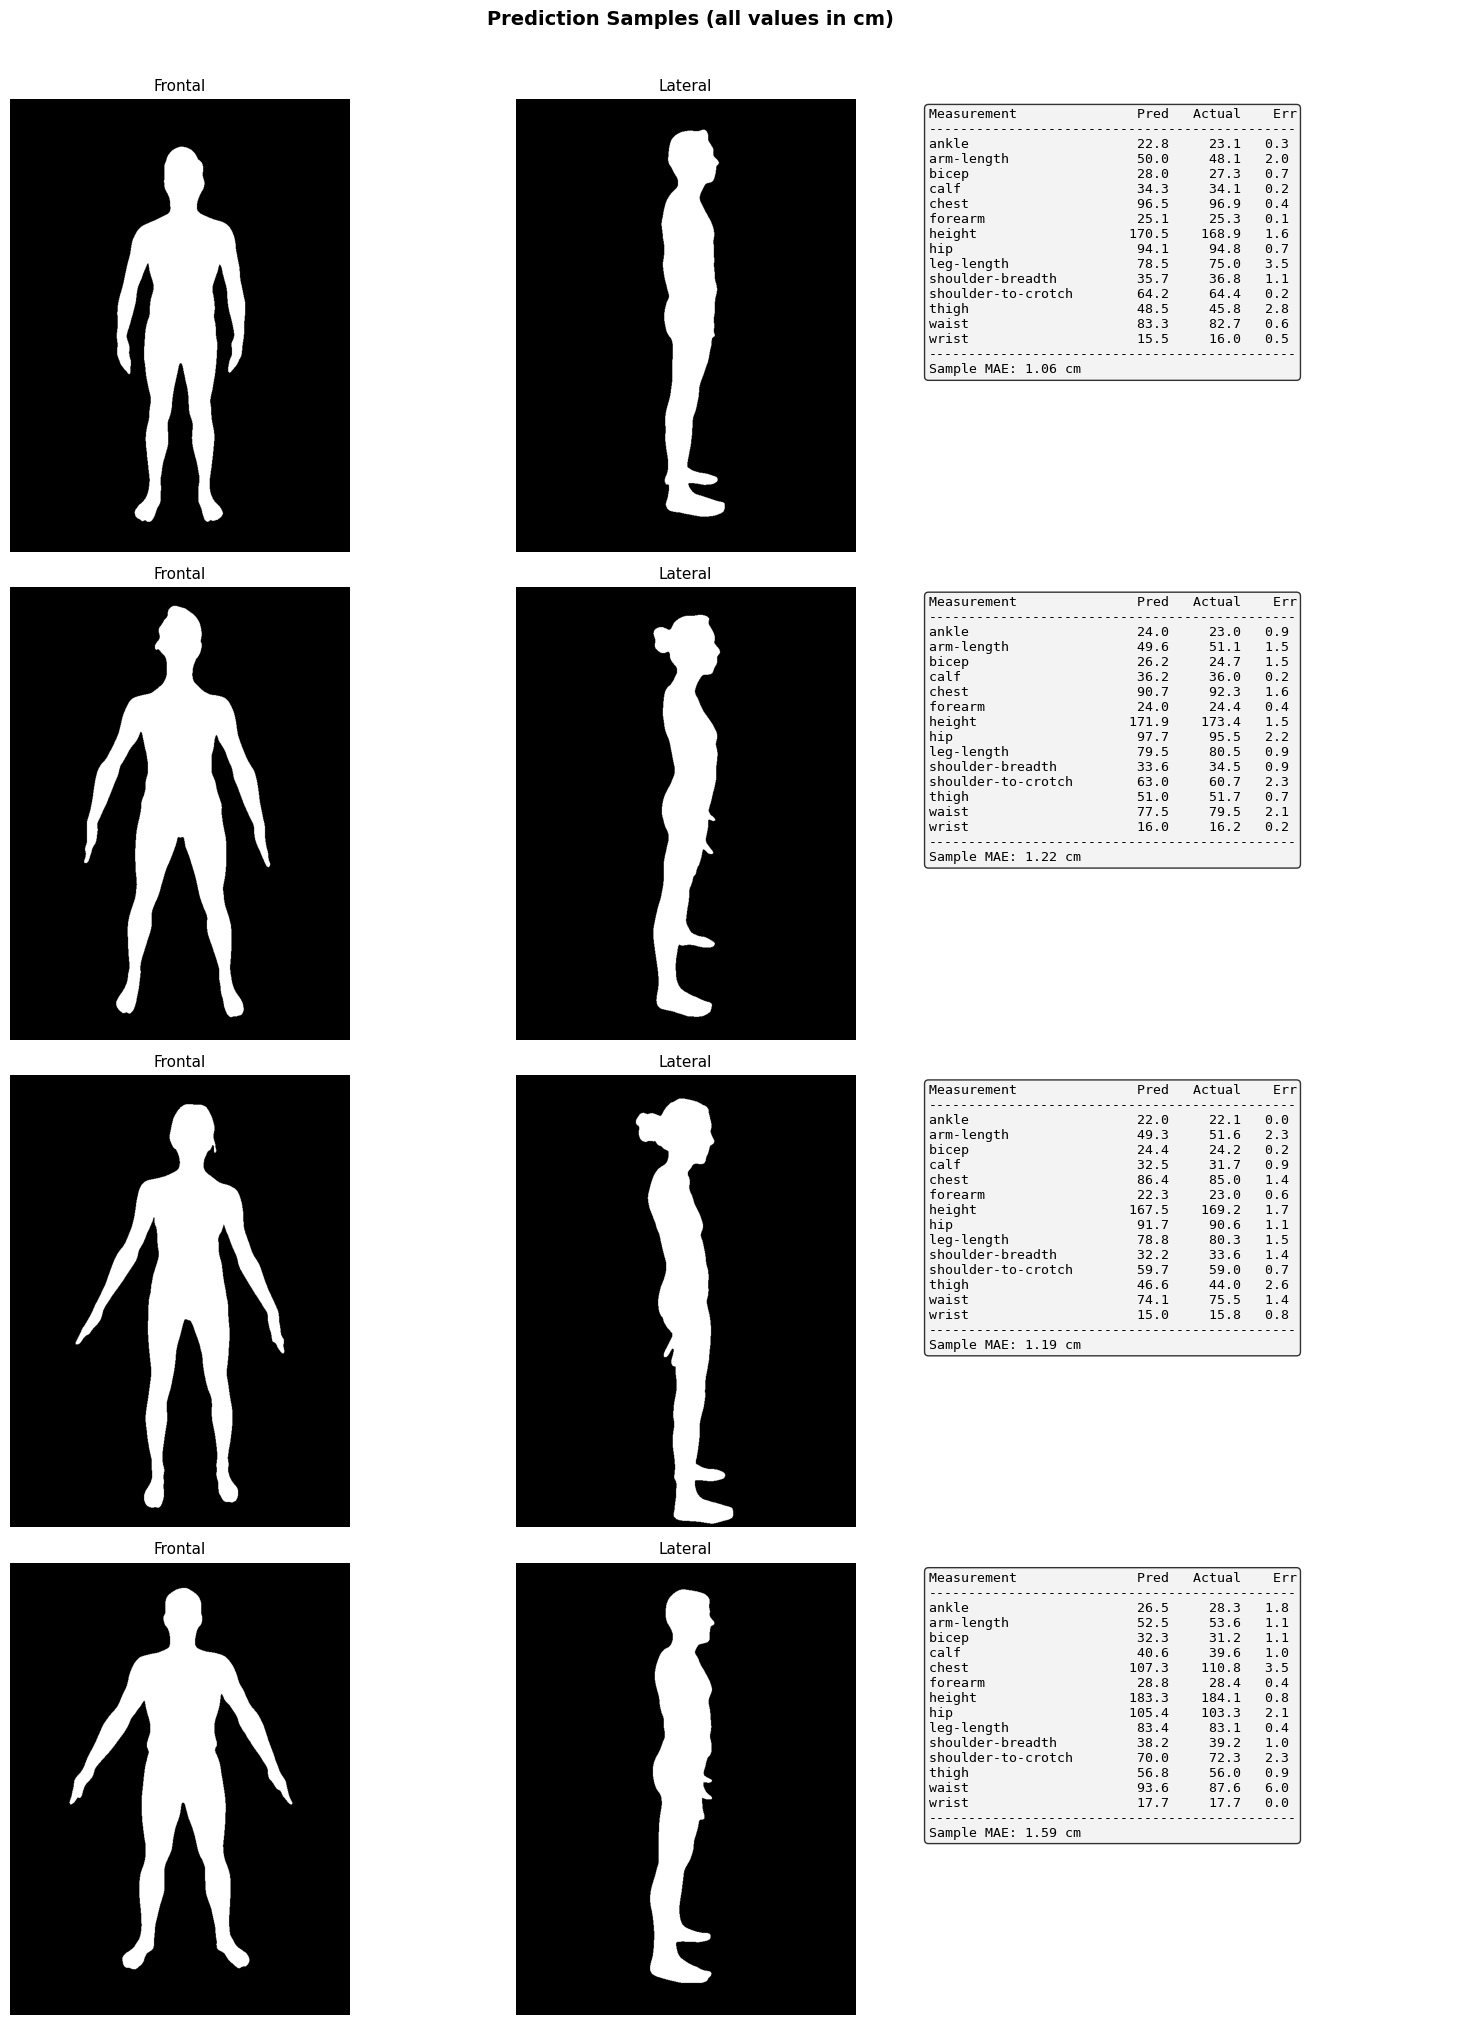

In [24]:
@torch.no_grad()
def collect_all_predictions(model, loader, scaler, device):
    model.eval()
    all_preds, all_labels = [], []
    for front, side, gender, labels in loader:
        preds = model(front.to(device), side.to(device), gender.to(device))
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_preds  = scaler.inverse_transform(np.vstack(all_preds))
    all_labels = scaler.inverse_transform(np.vstack(all_labels))
    return all_preds, all_labels

test_preds_cm, test_labels_cm = collect_all_predictions(model, test_loader, scaler, DEVICE)

def show_prediction_samples(test_df, test_preds_cm, test_labels_cm, num_samples=4):
    indices = random.sample(range(len(test_df)), num_samples)
    fig, axes = plt.subplots(num_samples, 3, figsize=(16, num_samples * 5))

    for row_i, idx in enumerate(indices):
        photo_id = test_df.iloc[idx]['photo_id']
        pred   = test_preds_cm[idx]
        actual = test_labels_cm[idx]

        front_img = cv2.imread(os.path.join(mask_dir,      f'{photo_id}.png'), 0)
        side_img  = cv2.imread(os.path.join(mask_left_dir, f'{photo_id}.png'), 0)

        axes[row_i, 0].imshow(front_img, cmap='gray')
        axes[row_i, 0].set_title('Frontal', fontsize=11); axes[row_i, 0].axis('off')

        axes[row_i, 1].imshow(side_img, cmap='gray')
        axes[row_i, 1].set_title('Lateral', fontsize=11); axes[row_i, 1].axis('off')

        axes[row_i, 2].axis('off')
        txt_lines = [f"{'Measurement':<22} {'Pred':>7} {'Actual':>8} {'Err':>6}"]
        txt_lines.append('-' * 46)
        for col, p, a in zip(MEASUREMENT_COLS, pred, actual):
            err = abs(p - a)
            txt_lines.append(f'{col:<22} {p:>7.1f} {a:>8.1f} {err:>5.1f}')
        mae = np.mean(np.abs(pred - actual))
        txt_lines.append('-' * 46)
        txt_lines.append(f'Sample MAE: {mae:.2f} cm')
        axes[row_i, 2].text(0.02, 0.98, '\n'.join(txt_lines),
                            transform=axes[row_i, 2].transAxes,
                            fontsize=9.5, verticalalignment='top',
                            family='monospace',
                            bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

    plt.suptitle('Prediction Samples (all values in cm)', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'prediction_samples.png'), dpi=150, bbox_inches='tight')
    plt.show()

show_prediction_samples(test_df, test_preds_cm, test_labels_cm, num_samples=4)

## 14. Error Analysis

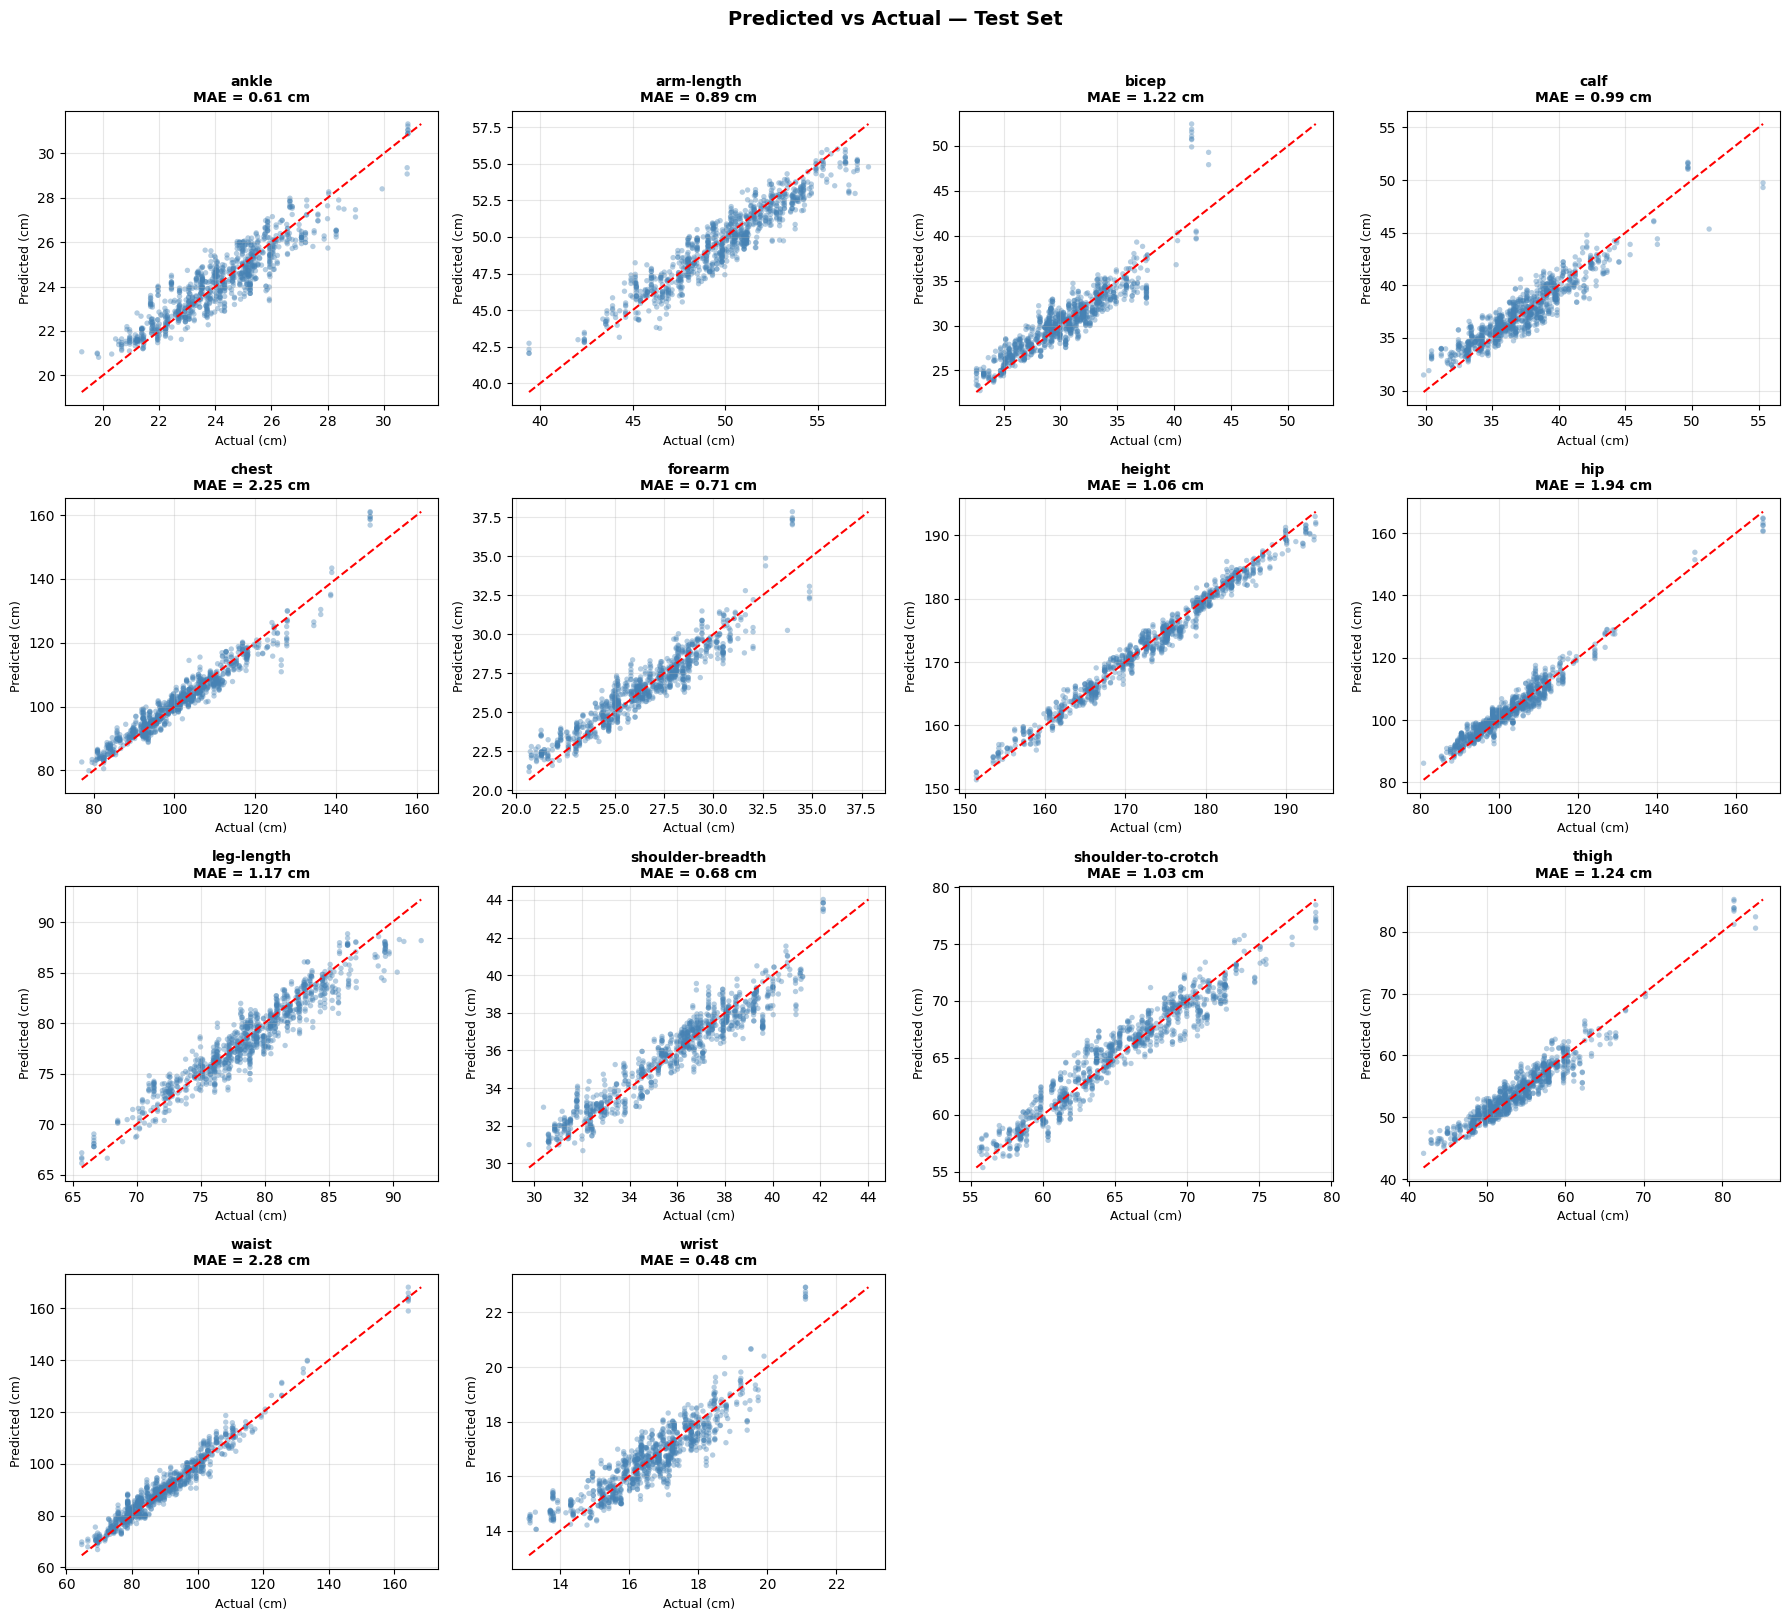

In [25]:
# ─── Predicted vs Actual scatter plots ────────────────────────────────────────
n_cols  = 4
n_rows  = (NUM_OUTPUTS + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.ravel()

for i, col in enumerate(MEASUREMENT_COLS):
    ax = axes[i]
    ax.scatter(test_labels_cm[:, i], test_preds_cm[:, i],
               alpha=0.4, s=15, color='steelblue', edgecolors='none')
    lims = [min(test_labels_cm[:, i].min(), test_preds_cm[:, i].min()),
            max(test_labels_cm[:, i].max(), test_preds_cm[:, i].max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect')
    ax.set_xlabel('Actual (cm)', fontsize=9)
    ax.set_ylabel('Predicted (cm)', fontsize=9)
    mae = np.abs(test_labels_cm[:, i] - test_preds_cm[:, i]).mean()
    ax.set_title(f'{col}\nMAE = {mae:.2f} cm', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)

# Hide unused subplots
for j in range(len(MEASUREMENT_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Predicted vs Actual — Test Set', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'scatter_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ─── Gender breakdown of MAE ──────────────────────────────────────────────────
gender_labels = test_df['gender'].values
errors_cm     = np.abs(test_preds_cm - test_labels_cm)

print(f'\n{"="*55}')
print(f' MAE (cm) by Gender')
print(f'{"="*55}')
print(f' {"Measurement":<25} {"Female":>10} {"Male":>10}')
print(f'{"─"*55}')

for i, col in enumerate(MEASUREMENT_COLS):
    female_mae = errors_cm[gender_labels == 'female', i].mean() if (gender_labels == 'female').any() else float('nan')
    male_mae   = errors_cm[gender_labels == 'male',   i].mean() if (gender_labels == 'male').any()   else float('nan')
    print(f' {col:<25} {female_mae:>10.3f} {male_mae:>10.3f}')

print(f'{"="*55}')

female_mean = errors_cm[gender_labels == 'female'].mean() if (gender_labels == 'female').any() else float('nan')
male_mean   = errors_cm[gender_labels == 'male'].mean()   if (gender_labels == 'male').any()   else float('nan')
print(f' {"MEAN (all cols)":<25} {female_mean:>10.3f} {male_mean:>10.3f}')
print(f'{"="*55}')


 MAE (cm) by Gender
 Measurement                   Female       Male
───────────────────────────────────────────────────────
 ankle                          0.630      0.596
 arm-length                     0.912      0.882
 bicep                          1.201      1.236
 calf                           1.027      0.959
 chest                          2.560      2.045
 forearm                        0.728      0.703
 height                         1.090      1.039
 hip                            1.966      1.925
 leg-length                     1.198      1.143
 shoulder-breadth               0.679      0.677
 shoulder-to-crotch             0.875      1.133
 thigh                          1.163      1.295
 waist                          2.141      2.375
 wrist                          0.525      0.454
 MEAN (all cols)                1.193      1.176


## 15. Save & Export Model

In [29]:
# ─── Save full checkpoint ─────────────────────────────────────────────────────
final_ckpt_path = os.path.join(OUTPUT_DIR, 'bodym_final_model.pth')
torch.save({
    'model_state_dict'  : model.state_dict(),
    'measurement_cols'  : MEASUREMENT_COLS,
    'scaler'            : scaler,
    'img_size'          : IMG_SIZE,
    'imagenet_mean'     : IMAGENET_MEAN,
    'imagenet_std'      : IMAGENET_STD,
    'test_mean_mae_cm'  : test_mean_mae,
}, final_ckpt_path)
print(f' Final model saved → {final_ckpt_path}')

✓ Final model saved → /kaggle/working/bodym_final_model.pth


In [33]:
import subprocess
subprocess.run(['pip', 'install', 'onnx', 'onnxscript', '-q'])
import onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 10.2 MB/s eta 0:00:00


In [34]:
import torch.nn as nn

class DualBranchONNXWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        front = x[:, 0:3, :, :]
        side  = x[:, 3:6, :, :]
        aux   = x[:, 6:9, 0, 0]
        return self.model(front, side, aux)

onnx_model  = DualBranchONNXWrapper(model).cpu().eval()
dummy_input = torch.zeros(1, 9, IMG_SIZE, IMG_SIZE)
onnx_path   = os.path.join(OUTPUT_DIR, 'bodym_model.onnx')

torch.onnx.export(
    onnx_model,
    dummy_input,
    onnx_path,
    input_names   = ['input'],
    output_names  = ['measurements'],
    dynamic_axes  = {'input': {0: 'batch_size'}, 'measurements': {0: 'batch_size'}},
    opset_version = 18,  # use 18 since 12 was failing anyway
    verbose       = False,
)
print(f'✓ ONNX model exported → {onnx_path}')

W0310 17:33:02.077000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0310 17:33:02.079000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0310 17:33:02.082000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0310 17:33:02.084000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


Applied 281 of general pattern rewrite rules.
✓ ONNX model exported → /kaggle/working/bodym_model.onnx


In [35]:
import subprocess
subprocess.run(['pip', 'install', 'onnxruntime', '-q'])

CompletedProcess(args=['pip', 'install', 'onnxruntime', '-q'], returncode=0)

In [36]:
import onnxruntime as ort
import numpy as np

model.eval()
front, side, aux, true_labels = next(iter(val_loader))

with torch.no_grad():
    pytorch_raw = model(front[0:1].cpu(), side[0:1].cpu(), aux[0:1].cpu()).numpy()[0]

print("PyTorch raw output:")
print(pytorch_raw)

front_np  = front[0].numpy()
side_np   = side[0].numpy()
aux_np    = aux[0].numpy()
aux_tiled = np.tile(aux_np[:, None, None], (1, 224, 224))
input_tensor = np.concatenate([front_np, side_np, aux_tiled], axis=0)[np.newaxis].astype(np.float32)

session  = ort.InferenceSession(onnx_path)
onnx_raw = session.run(None, {session.get_inputs()[0].name: input_tensor})[0][0]

print("\nONNX raw output:")
print(onnx_raw)
print("\nMax difference:", np.max(np.abs(pytorch_raw - onnx_raw)))
print("Are they close?", np.allclose(pytorch_raw, onnx_raw, atol=0.1))

predicted_cm = scaler.inverse_transform(pytorch_raw.reshape(1, -1))[0]
print("\nPyTorch → inverse scaled (cm):")
for col, val in zip(MEASUREMENT_COLS, predicted_cm):
    print(f"  {col:<25}: {val:.1f}")

PyTorch raw output:
[ 0.10344276  0.09885515  0.12890883  0.39131442  0.19551097  0.00350342
  0.12197277  0.61201894  0.39820647 -0.47619718 -0.23361161  0.63266146
  0.23794207  0.16114533]

ONNX raw output:
[ 0.10343029  0.0988615   0.12889618  0.39129704  0.19550358  0.0034921
  0.12197347  0.6120105   0.3982121  -0.47620103 -0.23361555  0.6326544
  0.23793277  0.16113561]

Max difference: 1.7374754e-05
Are they close? True

PyTorch → inverse scaled (cm):
  ankle                    : 24.4
  arm-length               : 49.8
  bicep                    : 31.1
  calf                     : 38.8
  chest                    : 104.2
  forearm                  : 26.6
  height                   : 173.1
  hip                      : 109.1
  leg-length               : 80.1
  shoulder-breadth         : 34.5
  shoulder-to-crotch       : 63.8
  thigh                    : 57.9
  waist                    : 93.5
  wrist                    : 16.9
